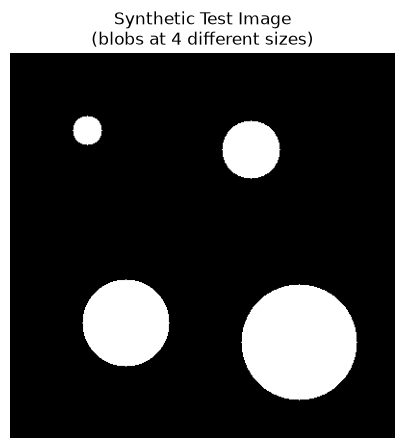

4 blobs built at radii 15, 30, 45, 60 px.
A working scale-invariant detector should find keypoints at all 4,
each with a keypoint 'size' roughly proportional to the blob's actual radius.


In [1]:
# ============================================
# Phase 2 — Day 13: SIFT Detector
# Scale-invariant keypoint detection & descriptors
# ============================================

import cv2
import numpy as np
import matplotlib.pyplot as plt 

# Build a synthetic image with circular blobs at DIFFERENT sizes
# -> this directly tests scale-invariance: does SIFT find both
#    the small blob and the large blob, each at its own matching scale?
canvas = np.zeros((400,400), dtype=np.uint8)

# Blob of increasing size 
cv2.circle(canvas, (80,80),15, 255, -1)     #small 
cv2.circle(canvas, (250, 100), 30, 255, -1) #medium
cv2.circle(canvas, (120, 280), 45, 255, -1) #large 
cv2.circle(canvas, (300, 300), 60, 255, -1) #extra large 

plt.figure(figsize=(5,5))
plt.imshow(canvas, cmap='gray')
plt.title('Synthetic Test Image\n(blobs at 4 different sizes)')
plt.axis('off')
plt.show()

print("4 blobs built at radii 15, 30, 45, 60 px.")
print("A working scale-invariant detector should find keypoints at all 4,")
print("each with a keypoint 'size' roughly proportional to the blob's actual radius.")

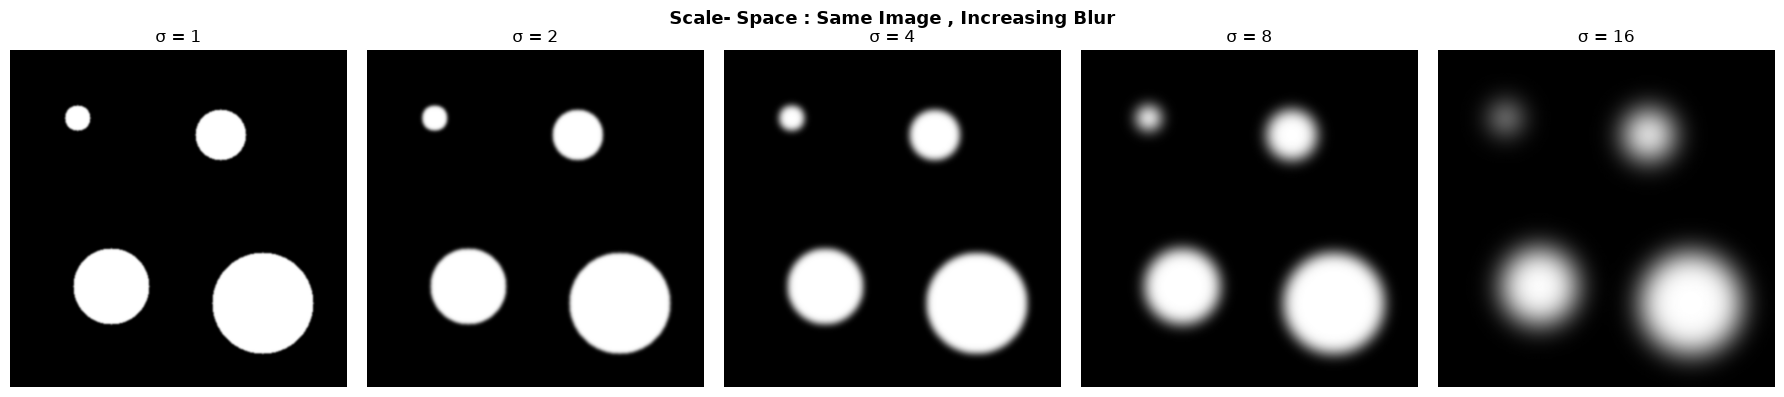

Watch the small blob (top-left, r=15) -- it should visibly start
dissolving into the background by around sigma=8, while the large
blob (bottom-right, r=60) still looks mostly like a solid blob.
This is exactly why one fixed 'best' sigma can't work for all blob sizes.


In [7]:
# ============================================
# Build a scale-space: same image, increasing blur (sigma)
# This is literally what SIFT does internally before DoG
# ============================================

sigmas = [1, 2, 4, 8, 16 ]
scale_space = [cv2.GaussianBlur(canvas, (0,0), sigmaX= s ) for s in sigmas]

fig, axes= plt.subplots(1, len(sigmas), figsize = (18,4))
for ax, img, s in zip(axes, scale_space, sigmas):
    ax.imshow(img, cmap='gray')
    ax.set_title(f'σ = {s}')
    ax.axis('off')

plt.suptitle('Scale- Space : Same Image , Increasing Blur', fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.show()

print("Watch the small blob (top-left, r=15) -- it should visibly start")
print("dissolving into the background by around sigma=8, while the large")
print("blob (bottom-right, r=60) still looks mostly like a solid blob.")
print("This is exactly why one fixed 'best' sigma can't work for all blob sizes.")

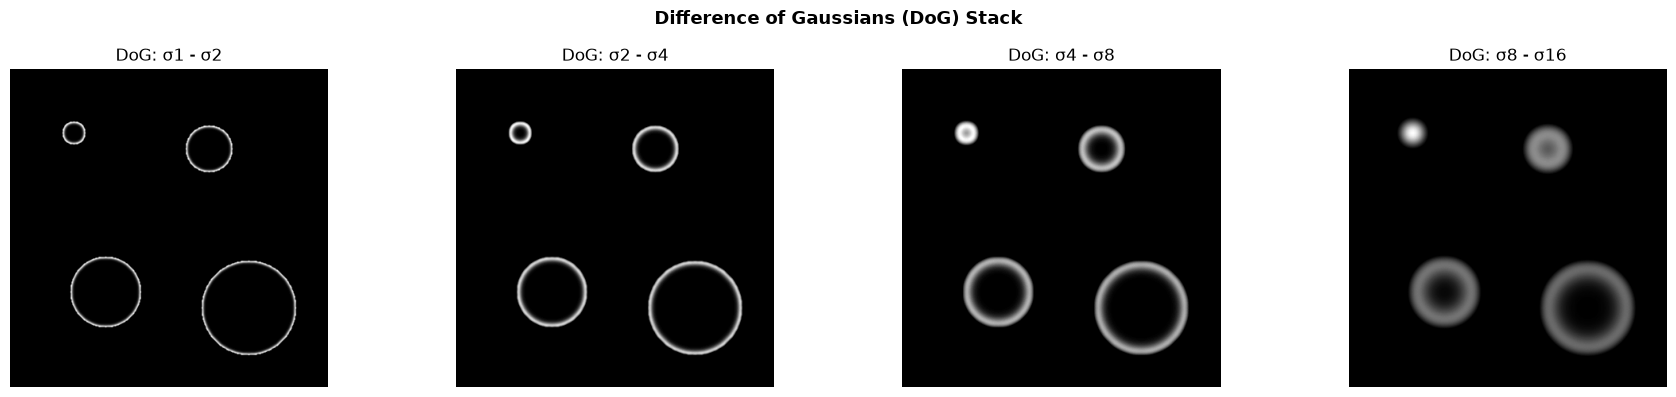

Look for: does each blob 'light up' (bright ring/blob response) most
strongly in a DIFFERENT DoG layer depending on its size?
Small blob should peak in an early (small sigma-gap) layer.
Large blob should peak in a later (large sigma-gap) layer.


In [8]:
# ============================================
# Difference of Gaussians (DoG) -- subtract adjacent scale-space layers
# This approximates blob detection cheaply (stand-in for Laplacian of Gaussian)
# ============================================

dog_stack = []
for i in range(len(scale_space) - 1):
    dog = cv2.subtract(scale_space[i], scale_space[i+1])
    dog_stack.append(dog)

fig, axes = plt.subplots(1, len(dog_stack), figsize=(18, 4))
for ax, dog, s1, s2 in zip(axes, dog_stack, sigmas[:-1], sigmas[1:]):
    ax.imshow(dog, cmap='gray')
    ax.set_title(f'DoG: σ{s1} - σ{s2}')
    ax.axis('off')

plt.suptitle('Difference of Gaussians (DoG) Stack', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Look for: does each blob 'light up' (bright ring/blob response) most")
print("strongly in a DIFFERENT DoG layer depending on its size?")
print("Small blob should peak in an early (small sigma-gap) layer.")
print("Large blob should peak in a later (large sigma-gap) layer.")

Number of keypoints detected: 41
Descriptor shape: (41, 128)

Keypoint 0: pos=(78.0, 273.0) size=3.8  angle=6.6°  response=0.0636
Keypoint 1: pos=(80.2, 80.2) size=19.3  angle=51.5°  response=0.1679
Keypoint 2: pos=(80.2, 80.2) size=19.3  angle=92.6°  response=0.1679
Keypoint 3: pos=(80.2, 80.2) size=19.3  angle=118.4°  response=0.1679
Keypoint 4: pos=(80.2, 80.2) size=19.3  angle=180.1°  response=0.1679
Keypoint 5: pos=(80.2, 80.2) size=19.3  angle=217.9°  response=0.1679
Keypoint 6: pos=(80.2, 80.2) size=19.3  angle=269.9°  response=0.1679
Keypoint 7: pos=(80.2, 80.2) size=19.3  angle=331.6°  response=0.1679
Keypoint 8: pos=(80.2, 80.2) size=19.3  angle=357.4°  response=0.1679
Keypoint 9: pos=(113.0, 238.0) size=3.8  angle=83.4°  response=0.0636
Keypoint 10: pos=(120.2, 280.3) size=57.0  angle=34.9°  response=0.1687
Keypoint 11: pos=(120.2, 280.3) size=57.0  angle=90.0°  response=0.1687
Keypoint 12: pos=(120.2, 280.3) size=57.0  angle=123.6°  response=0.1687
Keypoint 13: pos=(120.2, 

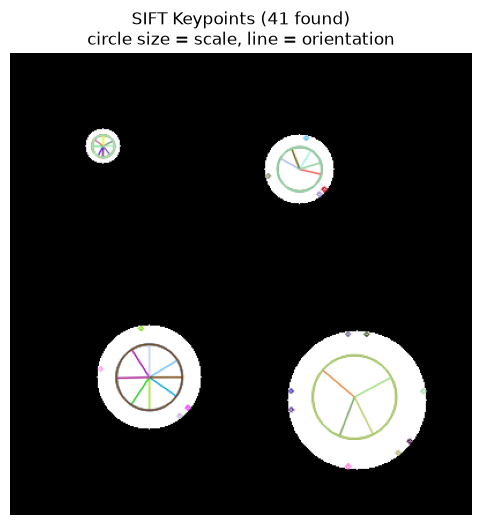

In [10]:
# ============================================
# Run actual SIFT detector + descriptor
# ============================================

sift = cv2.SIFT_create()

keypoints , descriptors = sift.detectAndCompute(canvas, None)

print(f"Number of keypoints detected: {len(keypoints)}")
print(f"Descriptor shape: {descriptors.shape}")  # (num_keypoints, 128)
print()

# Print eachkeypoints key properties 
for i, kp in enumerate(keypoints):
    print(f'Keypoint {i}: pos=({kp.pt[0]:.1f}, {kp.pt[1]:.1f}) size={kp.size:.1f}  angle={kp.angle:.1f}°  response={kp.response:.4f}')


# Draw keypoints -- Flag draws a circle sized to kp.size and a line for orientation 
result = cv2.drawKeypoints(
    cv2.cvtColor(canvas, cv2.COLOR_GRAY2BGR),
    keypoints, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title(f'SIFT Keypoints ({len(keypoints)} found)\ncircle size = scale, line = orientation')
plt.axis('off')
plt.show()

In [11]:
strong_keypoints = [kp for kp in keypoints if kp.response > 0.1]
print(f"Keypoints with response > 0.1: {len(strong_keypoints)}")
for kp in strong_keypoints:
    print(f"pos=({kp.pt[0]:.1f},{kp.pt[1]:.1f}) size={kp.size:.1f} response={kp.response:.4f}")
    

Keypoints with response > 0.1: 25
pos=(80.2,80.2) size=19.3 response=0.1679
pos=(80.2,80.2) size=19.3 response=0.1679
pos=(80.2,80.2) size=19.3 response=0.1679
pos=(80.2,80.2) size=19.3 response=0.1679
pos=(80.2,80.2) size=19.3 response=0.1679
pos=(80.2,80.2) size=19.3 response=0.1679
pos=(80.2,80.2) size=19.3 response=0.1679
pos=(80.2,80.2) size=19.3 response=0.1679
pos=(120.2,280.3) size=57.0 response=0.1687
pos=(120.2,280.3) size=57.0 response=0.1687
pos=(120.2,280.3) size=57.0 response=0.1687
pos=(120.2,280.3) size=57.0 response=0.1687
pos=(120.2,280.3) size=57.0 response=0.1687
pos=(120.2,280.3) size=57.0 response=0.1687
pos=(120.2,280.3) size=57.0 response=0.1687
pos=(120.2,280.3) size=57.0 response=0.1687
pos=(250.3,100.1) size=38.3 response=0.1678
pos=(250.3,100.1) size=38.3 response=0.1678
pos=(250.3,100.1) size=38.3 response=0.1678
pos=(250.3,100.1) size=38.3 response=0.1678
pos=(250.3,100.1) size=38.3 response=0.1678
pos=(297.8,297.3) size=72.3 response=0.1630
pos=(297.8,297

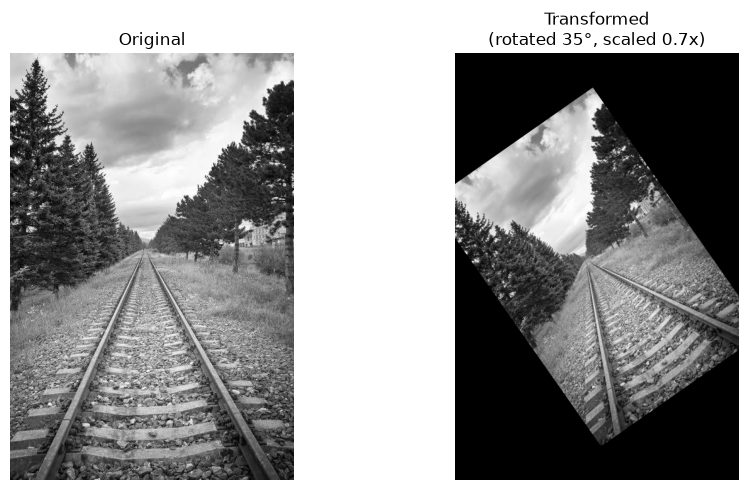

Image shape: (678, 452)
Goal: SIFT should find matching keypoints between these two,
despite the rotation and scale change -- that's the whole point



In [15]:
# ============================================
# Real photo test: SIFT matching across a transformed view
# (using your Day 12 train track photo instead of skimage)
# ============================================

# A photo with genuine texture/structure (not flat synthetic shapes)

original = cv2.imread('/home/arpeetpadhy/hough1.jpg')
original_gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)

h,w = original_gray.shape 

# Generate a transformed version: rotate 35 degrees + scale down to 70%
angle = 35 
scale = 0.7 
M = cv2.getRotationMatrix2D((w/2, h/2), angle , scale )
transformed_gray = cv2.warpAffine(original_gray, M, (w, h))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_gray, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(transformed_gray, cmap='gray')
axes[1].set_title(f'Transformed\n(rotated {angle}°, scaled {scale}x)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Image shape: {original_gray.shape}")
print("Goal: SIFT should find matching keypoints between these two,")
print("despite the rotation and scale change -- that's the whole point")
print()


Keypoints in Original : 3146
Keypoints in transformed: 1829
Raw matches found: 3146
Good matches (after ratio test): 1030


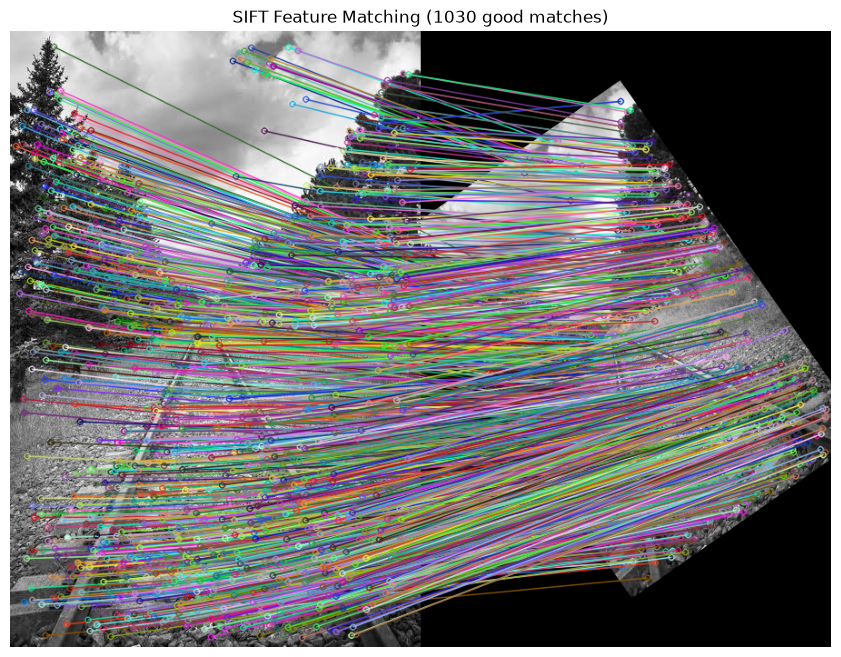

In [17]:
# ============================================
# Detect SIFT keypoints + descriptors on BOTH images,
# then match them using their 128-D descriptors
# ============================================

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(original_gray, None)
kp2, des2 = sift.detectAndCompute(transformed_gray, None)

print(f'Keypoints in Original : {len(kp1)}')
print(f"Keypoints in transformed: {len(kp2)}")

# BFMatcher: brute-force compares every descriptor in image 1
# against every descriptor in image 2, finds closest match by distance
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

# Lowe's ratio test: keep a match only if the best match is CLEARLY
# better than the second-best -- filters out ambiguous/ false matches

good_matches = []
for m,n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print(f"Raw matches found: {len(matches)}")
print(f"Good matches (after ratio test): {len(good_matches)}")

# Draw the matches -- lines connecting matched keypoints across both images
result = cv2.drawMatches(
    original_gray, kp1,
    transformed_gray, kp2,
    good_matches, None, 
    flags = cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS 
)
plt.figure(figsize=(16, 8))
plt.imshow(result, cmap='gray')
plt.title(f'SIFT Feature Matching ({len(good_matches)} good matches)')
plt.axis('off')
plt.show()